<h1> 8.1 Functional programming </h1>

In [1]:
def generate_five_adder():
    def _five_adder(a):
        return a + 5

    return _five_adder


coolfunction = generate_five_adder()
coolfunction(7)

12

In [2]:
def thirty_function():
    def times_three(a):
        return a * 3

    def add_seven(a):
        return a + 7

    return times_three(add_seven(3))


thirty_function()

30

In [3]:
add_seven

NameError: name 'add_seven' is not defined

In [4]:
print(thirty_function)

<function thirty_function at 0x108490c20>


In [6]:
def add_five(a):
    return a + 5

x = [thirty_function, add_five]

for fun in x:
    print(fun)

<function thirty_function at 0x108490c20>
<function add_five at 0x107ffd580>


In [7]:
def deferred_greeting():
    def greet():
        print("Hello")

    return greet


friendlyfunction = deferred_greeting()

In [8]:
# Do something else
print("Just passing the time...")
# OK, Go!
friendlyfunction()

Just passing the time...
Hello


In [9]:
def generate_adder(increment):
    def _adder(a):
        return a + increment

    return _adder


add_3 = generate_adder(3)

In [10]:
add_3(9)

12

In [11]:
add = generate_adder
add(8)(5)

13

In [12]:
# closure
name = "Eric"


def greet():
    print("Hello, ", name)


greet()

Hello,  Eric


In [13]:
name = "John"

greet()

Hello,  John


In [14]:
numbers = range(10)

[add_five(i) for i in numbers]

[5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [15]:
list(map(add_five, numbers))

[5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [16]:
def summer(data):
    total = 0.0

    for x in data:
        total += x

    return total

In [17]:
summer(range(10))

45.0

In [18]:
import sys


def my_max(data):
    # Start with the smallest possible number
    highest = -sys.float_info.max

    for x in data:
        if x > highest:
            highest = x

    return highest

In [19]:
my_max([2, 5, 10, -11, -5])

10

In [20]:
-sys.float_info.max

-1.7976931348623157e+308

In [21]:
def accumulate(operation, data, initial):
    accumulator = initial
    for x in data:
        accumulator = operation(accumulator, x)
    return accumulator


def my_sum(data):
    def _add(a, b):
        return a + b

    return accumulate(_add, data, 0)

my_sum(range(5))

10

In [22]:
def bigger(a, b):
    if b > a:
        return b
    return a


def my_max(data):
    return accumulate(bigger, data, -sys.float_info.max)


my_max([2, 5, 10, -11, -5])

10

In [23]:
from functools import reduce


def my_max(data):
    return reduce(bigger, data, -sys.float_info.max)


my_max([2, 5, 10, -11, -5])

10

In [24]:
def most_Cs_in_any_sequence(sequences):
    def count_Cs(sequence):
        return sequence.count("C")

    counts = map(count_Cs, sequences)
    return max(counts)


def most_Gs_in_any_sequence(sequences):
    return max(map(lambda sequence: sequence.count("G"), sequences))


data = ["CGTA", "CGGGTAAACG", "GATTACA"]

most_Gs_in_any_sequence(data)

4

In [25]:
func_name = lambda a, b, c: a + b + c


def func_name(a, b, c):
    return a + b + c

In [26]:
def most_of_given_base_in_any_sequence(sequences, base):
    return max(map(lambda sequence: sequence.count(base), sequences))


most_of_given_base_in_any_sequence(data, "A")

3

In [27]:
data = range(10)
list(map(lambda x: 2 * x, data))

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

In [28]:
[2 * x for x in data]

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

In [29]:
def my_max(data):
    return reduce(lambda a, b: a if a > b else b, data, -sys.float_info.max)


my_max([2, 5, 10, -11, -5])

10

Starting from 2, the root I found is 1.0
Starting from 0.2, the root I found is -3.441905100203782e-21


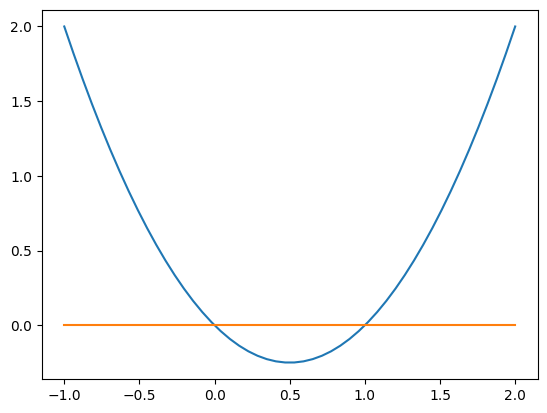

In [30]:
from matplotlib import pyplot as plt
from numpy import linspace, zeros
from scipy.optimize import newton

solve_me = lambda x: x**2 - x

for x0 in [2, 0.2]:
    answer = newton(solve_me, x0)
    print(f"Starting from {x0}, the root I found is {answer}")

xs = linspace(-1, 2, 50)
solved = [xs, list(map(solve_me, xs)), xs, zeros(len(xs))]

plt.plot(*solved)

In [31]:
def derivative_simple(func, eps, at):
    return (func(at + eps) - func(at)) / eps

In [32]:
def derivative(func, eps):
    def _func_derived(x):
        return (func(x + eps) - func(x)) / eps

    return _func_derived

straight = derivative(solve_me, 0.01)

In [33]:
straight(3)

5.00999999999987

0.495000000000001


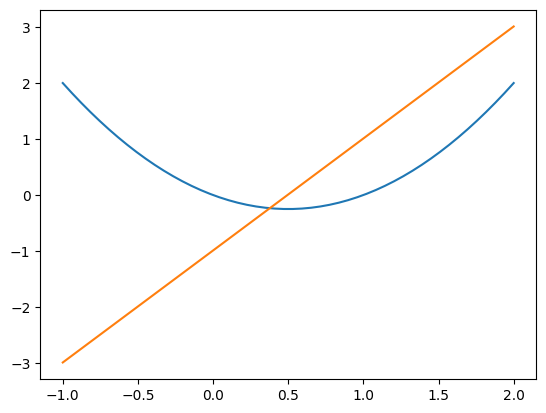

In [34]:
derived = (xs, list(map(solve_me, xs)), xs, list(map(derivative(solve_me, 0.01), xs)))
plt.plot(*derived)
print(newton(derivative(solve_me, 0.01), 0))

In [36]:
import scipy.misc


def derivative(func):
    def _func_derived(x):
        return scipy.mise.derivative(func, x)

    return _func_derived


newton(derivative(solve_me), 0)

AttributeError: Module 'scipy' has no attribute 'mise'

<h1> 8.2 Iterators and Generators <h1>

In [37]:
bowl = {"apple": 5, "banana": 3, "orange": 7}

for fruit in bowl:
    print(fruit.upper())

APPLE
BANANA
ORANGE


In [38]:
range(10)

range(0, 10)

In [39]:
total = 0
for x in range(int(1e6)):
    total += x

total

499999500000

In [40]:
for i in range(3):
    print(i)

0
1
2


In [41]:
a = iter(range(3))

In [42]:
next(a)

0

In [43]:
next(a)

1

In [44]:
next(a)

2

In [45]:
next(a)

StopIteration: 

In [46]:
list(range(5))

[0, 1, 2, 3, 4]

In [47]:
class fib_iterator:
    """An iterator over part of the Fibonacci sequence."""

    def __init__(self, limit, seed1=1, seed2=1):
        self.limit = limit
        self.previous = seed1
        self.current = seed2

    def __iter__(self):
        return self

    def __next__(self):
        (self.previous, self.current) = (self.current, self.previous + self.current)
        self.limit -= 1
        if self.limit < 0:
            raise StopIteration()
        return self.current

In [48]:
x = fib_iterator(5)

In [49]:
next(x)

2

In [50]:
next(x)

3

In [51]:
next(x)

5

In [52]:
next(x)

8

In [53]:
for x in fib_iterator(5):
    print(x)

2
3
5
8
13


In [54]:
sum(fib_iterator(1000))

297924218508143360336882819981631900915673130543819759032778173440536722190488904520034508163846345539055096533885943242814978469042830417586260359446115245634668393210192357419233828310479227982326069668668250

In [55]:
from matplotlib import pyplot as plt
from numpy import array


class MyImage:
    def __init__(self, pixels):
        self.pixels = array(pixels, dtype="uint8")
        self.channels = self.pixels.shape[2]

    def __iter__(self):
        # return an iterator over just the pixel values
        return iter(self.pixels.reshape(-1, self.channels))

    def show(self):
        plt.imshow(self.pixels, interpolation="None")


x = [[[255, 255, 0], [0, 255, 0]], [[0, 0, 255], [255, 255, 255]]]
image = MyImage(x)

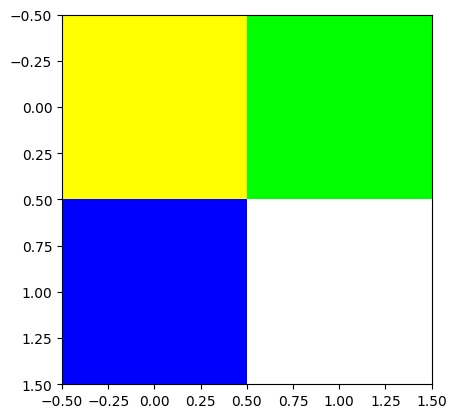

In [56]:
image.show()

In [57]:
image.channels

3

In [58]:
from webcolors import rgb_to_name

for pixel in image:
    print(rgb_to_name(pixel))

yellow
lime
blue
white


In [59]:
def my_generator():
    yield 5
    yield 10


x = my_generator()

In [60]:
next(x)

5

In [61]:
next(x)

10

In [62]:
next(x)

StopIteration: 

In [63]:
for a in my_generator():
    print(a)

5
10


In [64]:
sum(my_generator())

15

In [65]:
# Genertor 
def yield_fibs(limit, seed1=1, seed2=1):
    current = seed1
    previous = seed2

    while limit > 0:
        limit -= 1
        current, previous = current + previous, current
        yield current

In [66]:
sum(yield_fibs(5))

31

In [67]:
for a in yield_fibs(10):
    if a % 2 == 0:
        print(a)

2
8
34
144


In [68]:
list(yield_fibs(10))

[2, 3, 5, 8, 13, 21, 34, 55, 89, 144]

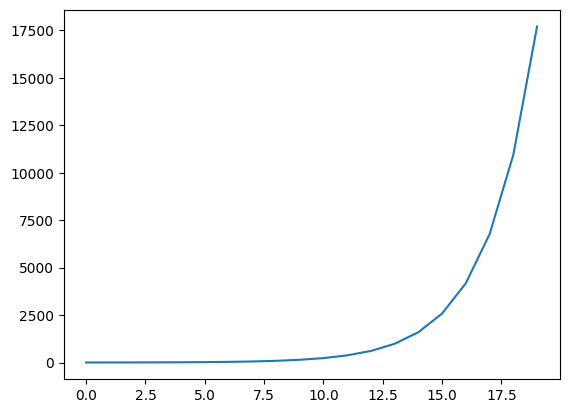

In [69]:
plt.plot(list(yield_fibs(20)))

In [70]:
import yaml

with open("example.yaml") as foo:
    print(yaml.safe_load(foo))

{'modelname': 'brilliant'}


In [71]:
class verbose_context:
    def __init__(self, name):
        self.name = name

    def __enter__(self):
        print("Get ready, ", self.name)

    def __exit__(self, exc_type, exc_value, traceback):
        print("OK, done")


with verbose_context("Monty"):
    print("Doing it!")

Get ready,  Monty
Doing it!
OK, done


In [72]:
from contextlib import contextmanager


@contextmanager
def verbose_context(name):
    print("Get ready for action, ", name)
    yield name.upper()
    print("You did it")


with verbose_context("Monty") as shouty:
    print(f"Doing it, {shouty}")

Get ready for action,  Monty
Doing it, MONTY
You did it


In [73]:
def repeat(func):
    def _repeated(x):
        return func(func(x))

    return _repeated


def hello(name):
    return f"Hello, {name}"


print(hello("Cleese"))
print(repeat(hello)("Cleese"))

Hello, Cleese
Hello, Hello, Cleese


In [74]:
@repeat
def hello(name):
    return f"Hello, {name}"


hello("Cleese")

'Hello, Hello, Cleese'

In [75]:
def repeater(count):
    def wrap_function_in_repeat(func):
        def _repeated(x):
            counter = count
            while counter > 0:
                counter -= 1
                x = func(x)
            return x

        return _repeated

    return wrap_function_in_repeat

In [76]:
from math import sqrt

fiftytimes = repeater(50)
fiftyroots = fiftytimes(sqrt)

fiftyroots(100)

1.000000000000004

In [77]:
@repeater(3)
def hello(name):
    return f"Hello, {name}"


hello("Cleese")

'Hello, Hello, Hello, Cleese'

In [78]:
# test generators
import os


def assert_exemplar(**fixture):
    answer = fixture.pop("answer")
    assert_equal(greet(**fixture), answer)


def test_greeter():
    with open(
        os.path.join(os.path.dirname(__file__), "fixtures", "samples.yaml")
    ) as fixtures_file:
        fixtures = yaml.safe_load(fixtures_file)

        for fixture in fixtures:
            yield assert_exemplar(**fixture)

In [79]:
from pytest import raises

with raises(AttributeError):
    x = 2
    x.foo()

In [80]:
@contextmanager
def reimplement_raises(exception):
    try:
        yield
    except exception:
        pass
    else:
        raise Exception("Expected,", exception, " to be raised, nothing was.")

In [81]:
with reimplement_raises(AttributeError):
    x = 2
    x.foo()

In [83]:
! pytest test_skipped.py

/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/_pytest/config/__init__.py:328: PluggyTeardownRaisedWarning: A plugin raised an exception during an old-style hookwrapper teardown.
Plugin: helpconfig, Hook: pytest_cmdline_parse
ImportError: cannot import name 'tarfile' from 'backports' (/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/backports/__init__.py)
For more information see https://pluggy.readthedocs.io/en/stable/api_reference.html#pluggy.PluggyTeardownRaisedWarning
  config = pluginmanager.hook.pytest_cmdline_parse(
Traceback (most recent call last):
  File "/Users/yuxinliu/anaconda3/bin/pytest", line 11, in <module>
    sys.exit(console_main())
             ^^^^^^^^^^^^^^
  File "/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/_pytest/config/__init__.py", line 189, in console_main
    code = main()
           ^^^^^^
  File "/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/_pytest/config/__init__.py", line 147, in main
    config = _prepareconfig(args,

In [84]:
! pytest test_not_skipped.py

/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/_pytest/config/__init__.py:328: PluggyTeardownRaisedWarning: A plugin raised an exception during an old-style hookwrapper teardown.
Plugin: helpconfig, Hook: pytest_cmdline_parse
ImportError: cannot import name 'tarfile' from 'backports' (/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/backports/__init__.py)
For more information see https://pluggy.readthedocs.io/en/stable/api_reference.html#pluggy.PluggyTeardownRaisedWarning
  config = pluginmanager.hook.pytest_cmdline_parse(
Traceback (most recent call last):
  File "/Users/yuxinliu/anaconda3/bin/pytest", line 11, in <module>
    sys.exit(console_main())
             ^^^^^^^^^^^^^^
  File "/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/_pytest/config/__init__.py", line 189, in console_main
    code = main()
           ^^^^^^
  File "/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/_pytest/config/__init__.py", line 147, in main
    config = _prepareconfig(args,

In [85]:
def homemade_skip_decorator(skip):
    def wrap_function(func):
        if skip:
            # if the test should be skipped, return a function
            # that just prints a message
            def do_nothing(*args):
                print("test was skipped")

            return do_nothing
        # otherwise use the original function as normal
        return func

    return wrap_function

In [86]:
@homemade_skip_decorator(3.9 < 4.0)
def test_skipped():
    raise RuntimeError("This test is skipped")


test_skipped()

test was skipped


In [87]:
@homemade_skip_decorator(3.9 < 3.0)
def test_runs():
    raise RuntimeError("This test is run")


test_runs()

RuntimeError: This test is run

<h1> 8.3 Exception <h1>

In [88]:
1 / 0

ZeroDivisionError: division by zero

In [89]:
import inspect

inspect.getmro(ZeroDivisionError)

(ZeroDivisionError, ArithmeticError, Exception, BaseException, object)

In [90]:
x = 1

for y in x:
    print(y)

TypeError: 'int' object is not iterable

In [91]:
inspect.getmro(TypeError)

(TypeError, Exception, BaseException, object)

In [92]:
class MyCustomErrorType(ArithmeticError):
    pass


raise MyCustomErrorType("Problem")

MyCustomErrorType: Problem

In [93]:
class MyCustomErrorType(Exception):
    def __init__(self, category=None):
        self.category = category

    def __str__(self):
        return f"Error, category {self.category}"


raise MyCustomErrorType(404)

MyCustomErrorType: Error, category 404

In [94]:
import yaml

try:
    config = yaml.safe_load(open("datasource.yaml"))
    user = config["userid"]
    password = config["password"]

except FileNotFoundError:
    print("No password file found, using anonymous user.")
    user = "anonymous"
    password = None


print(user)

No password file found, using anonymous user.
anonymous


In [95]:
try:
    config = yaml.safe_lod(open("datasource.yaml"))
    user = config["userid"]
    password = config["password"]
except:
    user = "anonymous"
    password = None

print(user)

anonymous


In [96]:
with open("datasource2.yaml", "w") as outfile:
    outfile.write("userid: eidle\n")
    outfile.write("password: secret\n")

with open("datasource3.yaml", "w") as outfile:
    outfile.write("user: eidle\n")
    outfile.write("password: secret\n")

In [97]:
def read_credentials(source):
    try:
        datasource = open(source)
        config = yaml.safe_load(datasource)
        user = config["userid"]
        password = config["password"]
        datasource.close()
    except FileNotFoundError:
        print("Password file missing")
        user = "anonymous"
        password = None
    except KeyError:
        print("Expected keys not found in file")
        user = "anonymous"
        password = None
    return user, password

In [98]:
print(read_credentials("datasource2.yaml"))

('eidle', 'secret')


In [99]:
print(read_credentials("datasource.yaml"))

Password file missing
('anonymous', None)


In [100]:
print(read_credentials("datasource3.yaml"))

Expected keys not found in file
('anonymous', None)


In [101]:
def read_credentials(source):
    try:
        datasource = open(source)
        config = yaml.safe_load(datasource)

        try:
            print("File loaded, trying to extract credentials")
            user = config["userid"]
            password = config["password"]
        except KeyError:
            print("Expected keys not found in file")
            user = "anonymous"
            password = None
        finally:
            # Runs irrespective of whether keys found
            print("Closing file")
            datasource.close()

    except FileNotFoundError:
        print("Password file missing")
        user = "anonymous"
        password = None

    return user, password

In [102]:
def read_credentials(source):
    try:
        datasource = open(source)

    except FileNotFoundError:
        print("Password file missing")
        user = "anonymous"
        password = None

    else:
        # Runs only if opening the file was successful
        config = yaml.safe_load(datasource)
        try:
            print("File loaded, trying to extract credentials")
            user = config["userid"]
            password = config["password"]
        except KeyError:
            print("Expected keys not found in file")
            user = "anonymous"
            password = None
        finally:
            # Runs irrespective of whether keys found
            print("Closing file")
            datasource.close()

    return user, password

In [103]:
def read_credentials(source):
    try:
        with open(source) as datasource:  # closes the file when done
            config = yaml.safe_load(datasource)
        user = config["userid"]
        password = config["password"]
    except FileNotFoundError:
        print("Password file missing")
        user = "anonymous"
        password = None
    except KeyError:
        print("Expected keys not found in file")
        user = "anonymous"
        password = None
    return user, password

In [104]:
def f4(x):
    if x == 0:
        return
    if x == 1:
        raise ArithmeticError()
    if x == 2:
        raise SyntaxError()
    if x == 3:
        raise TypeError()

In [105]:
def f3(x):
    try:
        print("F3Before")
        f4(x)
        print("F3After")
    except ArithmeticError:
        print("F3Except (💣)")

In [106]:
def f2(x):
    try:
        print("F2Before")
        f3(x)
        print("F2After")
    except SyntaxError:
        print("F2Except (💣)")

In [107]:
def f1(x):
    try:
        print("F1Before")
        f2(x)
        print("F1After")
    except TypeError:
        print("F1Except (💣)")

In [108]:
f1(0)

F1Before
F2Before
F3Before
F3After
F2After
F1After


In [109]:
f1(1)

F1Before
F2Before
F3Before
F3Except (💣)
F2After
F1After


In [110]:
f1(2)

F1Before
F2Before
F3Before
F2Except (💣)
F1After


In [111]:
f1(3)

F1Before
F2Before
F3Before
F1Except (💣)


In [112]:
import yaml


def analysis(source):
    if type(source) == dict:
        name = source["modelname"]
    else:
        content = open(source)
        source = yaml.safe_load(content)
        name = source["modelname"]
    print(name)

In [114]:
analysis({"modelname": "Super"})

Super


In [115]:
with open("example.yaml", "w") as outfile:
    outfile.write("modelname: brilliant\n")

In [116]:
analysis("example.yaml")

brilliant


In [117]:
with open("example.yaml", "w") as outfile:
    outfile.write("modelname: brilliant\n")

In [118]:
def analysis(source):
    try:
        name = source["modelname"]
    except TypeError:
        # Source was not a dictionary-like object
        # Maybe it is a file path
        try:
            content = open(source)
            source = yaml.safe_load(content)
            name = source["modelname"]
        except IOError:
            # Maybe it was already raw YAML content
            source = yaml.safe_load(source)
            name = source["modelname"]
    print(name)


analysis("modelname: Amazing")

Amazing


In [119]:
try:
    # Something
    pass
except:
    # Do this code here if anything goes wrong
    raise

In [120]:
def lower_function():
    raise ValueError("Error in lower function!")


def higher_function():
    try:
        lower_function()
    except ValueError as e:
        raise RuntimeError("Error in higher function!") from e


higher_function()

RuntimeError: Error in higher function!

<h1> 8.4 Operator overloading <h1>

In [122]:
4 + 2

6

In [123]:
"4" + "2"

'42'

In [124]:
6 * 7

42

In [125]:
"me" * 3

'mememe'

In [130]:
import os
from pathlib import Path

performance = Path("..") / "8. Advanced Programming Techniques"
os.listdir(performance)

['Advanced Programming Techniques.ipynb',
 'test_not_skipped.py',
 'test_skipped.py',
 'example.yaml',
 'datasource3.yaml',
 'datasource2.yaml']

In [131]:
performance = os.path.join("..", "8. Advanced Programming Techniques")

In [132]:
class Room:
    def __init__(self, name, area):
        self.name = name
        self.area = area
        
small = Room("small", 9)
print(small)

In [133]:
class Room:
    def __init__(self, name, area):
        self.name = name
        self.area = area

    def __str__(self):
        return f"<Room: {self.name} {self.area}m²>"
    
small = Room("small", 9)
print(small)

<Room: small 9m²>


In [134]:
class Room:
    def __init__(self, name, area):
        self.name = name
        self.area = area

    def __add__(self, other):
        return Room(f"{self.name}_{other.name}", self.area + other.area)

    def __str__(self):
        return f"<Room: {self.name} {self.area}m²>"
    
small = Room("small", 9)
big = Room("big", 21)
print(small, big, small + big)

<Room: small 9m²> <Room: big 21m²> <Room: small_big 30m²>


In [135]:
class Room:
    def __init__(self, name, area):
        self.name = name
        self.area = area

    def __add__(self, other):
        return Room(f"{self.name}_{other.name}", self.area + other.area)

    def __eq__(self, other):
        return self.area == other.area and set(self.name.split("_")) == set(
            other.name.split("_")
        )

small = Room("small", 9)
big = Room("big", 21)
large = Room("superbig", 30)
print(small + big == big + small)
print(small + big == large)

True
False


In [136]:
class Room:
    def __init__(self, name, area):
        self.name = name
        self.area = area
        self.occupants = []

    def add_occupant(self, name):
        self.occupants.append(name)


circus = Room("Circus", 3)
circus.add_occupant("Graham")
circus.add_occupant("Eric")
circus.add_occupant("Terry")

In [137]:
"John" in circus.occupants

False

In [138]:
class Room:
    def __init__(self, name, area):
        self.name = name
        self.area = area
        self.occupants = []

    def add_occupant(self, name):
        self.occupants.append(name)

    def __contains__(self, value):
        return value in self.occupants


circus = Room("Circus", 3)
circus.add_occupant("Graham")
circus.add_occupant("Eric")
circus.add_occupant("Terry")

"Terry" in circus

True

In [139]:
class Greeter:
    def __init__(self, greeting):
        self.greeting = greeting

    def __call__(self, name):
        print(self.greeting, name)


greeter_instance = Greeter("Hello")

greeter_instance("Eric")

Hello Eric


<h1> 8.5 Metaprogramming <h1>

In [140]:
bananas = 0
apples = 0
oranges = 0
bananas += 1
apples += 1
oranges += 1

In [141]:
initial_fruit_count = 0
bananas = initial_fruit_count
apples = initial_fruit_count
oranges = initial_fruit_count

In [142]:
class Basket:
    def __init__(self):
        self.count = 0

    def buy(self):
        self.count += 1


bananas = Basket()
apples = Basket()
oranges = Basket()
bananas.buy()
apples.buy()
oranges.buy()

In [143]:
baskets = [bananas, apples, oranges]
for basket in baskets:
    basket.buy()

In [144]:
baskets = [bananas, apples, oranges, kiwis]

NameError: name 'kiwis' is not defined

In [145]:
print("globals() is a\n", type(globals()))
print("\nWith these keys:\n", globals().keys())

globals() is a
 <class 'dict'>

With these keys:
 dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', 'generate_five_adder', 'coolfunction', '_1', 'sys', 'remove_imported_pydev_package', '_pydevd_bundle', 'pydev_jupyter_vars', '_i2', 'thirty_function', '_2', '_i3', '_i4', '_i5', '_i6', 'add_five', 'x', 'fun', '_i7', 'deferred_greeting', 'friendlyfunction', '_i8', '_i9', 'generate_adder', 'add_3', '_i10', '_10', '_i11', 'add', '_11', '_i12', 'name', 'greet', '_i13', '_i14', 'numbers', '_14', '_i15', '_15', '_i16', 'summer', '_i17', '_17', '_i18', 'my_max', '_i19', '_19', '_i20', '_20', '_i21', 'accumulate', 'my_sum', '_21', '_i22', 'bigger', '_22', '_i23', 'reduce', '_23', '_i24', 'most_Cs_in_any_sequence', 'most_Gs_in_any_sequence', 'data', '_24', '_i25', 'func_name', '_i26', 'most_of_given_base_in_an

In [146]:
globals()["apples"]

In [147]:
apples

In [148]:
basket_names = ["bananas", "apples", "oranges", "kiwis"]

for name in basket_names:
    globals()[name] = Basket()


kiwis.count

0

In [149]:
baskets = {}
for name in basket_names:
    baskets[name] = Basket()

baskets["kiwis"].count

0

In [150]:
baskets = {name: Basket() for name in baskets}
baskets["kiwis"].count

0

In [152]:
class Boring:
    pass

x = Boring()
x.name = "Michael"
x.name

'Michael'

In [153]:
x.__dict__

{'name': 'Michael'}

In [154]:
getattr(x, "name")

'Michael'

In [155]:
setattr(x, "age", 75)

x.age

75

In [156]:
setattr(Boring, "describe", lambda self: f"{self.name} is {self.age}")
x.describe()

'Michael is 75'

In [157]:
x.describe

<bound method <lambda> of <__main__.Boring object at 0x12ac08210>>

In [158]:
Boring.describe

<function __main__.<lambda>(self)>

In [160]:
y = Boring()
y.name = "Terry"
y.age = 78
y.describe()

'Terry is 78'

In [161]:
import datetime

def broken_birth_year(b_instance):
    current = datetime.datetime.now().year
    return current - b_instance.age

Boring.birth_year = broken_birth_year
x.birth_year()

1951

In [162]:
x.birth_year

<bound method broken_birth_year of <__main__.Boring object at 0x12ac08210>>

In [163]:
x.birth_year.__name__

'broken_birth_year'

In [164]:
class Person:
    def __init__(self, name, age, job, children_count):
        for var_name, value in locals().items():
            if var_name == "self":
                continue
            print(f"Setting self.{var_name} to {value}")
            setattr(self, var_name, value)

In [165]:
terry = Person("Terry", 78, "Screenwriter", 0)

Setting self.name to Terry
Setting self.age to 78
Setting self.job to Screenwriter
Setting self.children_count to 0


In [166]:
terry.first_name

AttributeError: 'Person' object has no attribute 'first_name'

In [167]:
class Person:
    def __init__(self, name, age, job, children_count):
        self.name = name
        self.age = age
        self.job = job
        self.children_count = children_count

<h1> 8.6 Advanced operator overloading <h1>

In [168]:
def extend(class_to_extend):
    """
    Metaprogramming to allow gradual implementation of class during notebook.
    Thanks to http://www.ianbicking.org/blog/2007/08/opening-python-classes.html
    """

    def decorator(extending_class):
        for name, value in extending_class.__dict__.items():
            if name in ["__dict__", "__module__", "__weakref__", "__doc__"]:
                continue
            setattr(class_to_extend, name, value)
        return class_to_extend

    return decorator

In [169]:
class Term:
    def __init__(self, symbols=[], powers=[], coefficient=1):
        self.coefficient = coefficient
        self.data = dict(zip(symbols, powers))
        
class Expression:
    def __init__(self, terms):
        self.terms = terms

In [170]:
first = Term(["x", "y"], [2, 1], 5)

second = Term(["x"], [1], 7)

third = Term([], [], 2)

result = Expression([first, second, third])

In [171]:
class Term:
    def __init__(self, *args):
        lead = args[0]
        if type(lead) == type(self):
            # Copy constructor
            self.data = dict(lead.data)
            self.coefficient = lead.coefficient
        elif type(lead) == int:
            self.from_constant(lead)
        elif type(lead) == str:
            self.from_symbol(*args)
        elif type(lead) == dict:
            self.from_dictionary(*args)
        else:
            self.from_lists(*args)

    def from_constant(self, constant):
        self.coefficient = constant
        self.data = {}

    def from_symbol(self, symbol, coefficient=1, power=1):
        self.coefficient = coefficient
        self.data = {symbol: power}

    def from_dictionary(self, data, coefficient=1):
        self.data = data
        self.coefficient = coefficient

    def from_lists(self, symbols=[], powers=[], coefficient=1):
        self.coefficient = coefficient
        self.data = dict(zip(symbols, powers))
        
class Expression:
    def __init__(self, terms=[]):
        self.terms = list(terms)
        
@extend(Term)
class Term:
    def add(self, *others):
        return Expression((self,) + others)
    
@extend(Term)
class Term:
    def multiply(self, *others):
        result_data = dict(self.data)
        result_coeff = self.coefficient
        # Convert arguments to Terms first if they are
        # constants or integers
        others = map(Term, others)

        for another in others:
            for symbol, power in another.data.items():
                if symbol in result_data:
                    result_data[symbol] += power  # add the powers together
                else:
                    result_data[symbol] = power
            result_coeff *= another.coefficient

        return Term(result_data, result_coeff)
    
@extend(Expression)
class Expression:
    def add(self, *others):
        result = Expression(self.terms)

        for another in others:
            if type(another) == Term:
                result.terms.append(another)
            else:
                result.terms += another.terms

        return result

In [172]:
x = Term("x")
y = Term("y")

first = Term(5).multiply(x, x, y)
second = Term(7).multiply(x)
third = Term(2)
expr = first.add(second, third)

In [173]:
@extend(Term)
class Term:
    def __add__(self, other):
        return self.add(other)

    def __mul__(self, other):
        return self.multiply(other)
    
@extend(Expression)
class Expression:
    def multiply(self, another):
        # Distributive law left as exercise
        pass

    def __add__(self, other):
        return self.add(other)

In [174]:
x_plus_y = Term("x") + "y"
x_plus_y.terms[1]

'y'

In [175]:
five_x_ysq = Term("x") * 5 * "y" * "y"

print(five_x_ysq.data, five_x_ysq.coefficient)

{'x': 1, 'y': 2} 5


In [176]:
@extend(Expression)
class Expression:
    def __radd__(self, other):
        return self.__add__(other)
    
@extend(Term)
class Term:
    def __rmul__(self, other):
        return self.__mul__(other)

    def __radd__(self, other):
        return self.__add__(other)

In [177]:
5 * Term("x")

In [178]:
fivex = 5 * Term("x")
fivex.data, fivex.coefficient

({'x': 1}, 5)

In [180]:
@extend(Term)
class Term:
    def __str__(self):
        def symbol_string(symbol, power):
            if power == 1:
                return symbol
            return f"{symbol}^{power}"

        symbol_strings = [
            symbol_string(symbol, power) for symbol, power in self.data.items()
        ]

        prod = "*".join(symbol_strings)

        if not prod:
            return str(self.coefficient)
        if self.coefficient == 1:
            return prod
        return f"{self.coefficient}*{prod}"
    
@extend(Expression)
class Expression:
    def __str__(self):
        return "+".join(map(str, self.terms))

In [181]:
first = Term(5) * "x" * "x" * "y"
second = Term(7) * "x"
third = Term(2)
expr = first + second + third
print(expr)

5*x^2*y+7*x+2
